# Uber NYC Data Analysis
This notebook explores and visualizes Uber pickup data in New York City.

In [1]:
# Import required libraries
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

## Load and Combine Data
Load all Uber CSV files into a single DataFrame.

In [2]:
data_path = os.getcwd()
csv_files = glob.glob(os.path.join(data_path, 'uber-raw-data-*.csv'))
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['DayOfWeek'] = df['Date/Time'].dt.day_name()
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['Month'] = df['Date/Time'].dt.month
df.head()

,Date/Time,Lat,Lon,Base,DayOfWeek,Hour,Day,Month
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,Tuesday,0,1,4
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,Tuesday,0,1,4
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,Tuesday,0,1,4
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,Tuesday,0,1,4
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,Tuesday,0,1,4


## Total Records
Display the total number of records in the dataset.

In [3]:
print('Total records:', len(df))

Total records: 3881892


## Pickups by Hour of Day
Visualize the number of Uber pickups for each hour of the day.

C:\Users\holsa\AppData\Local\Temp\ipykernel_26612\1681396335.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='viridis')


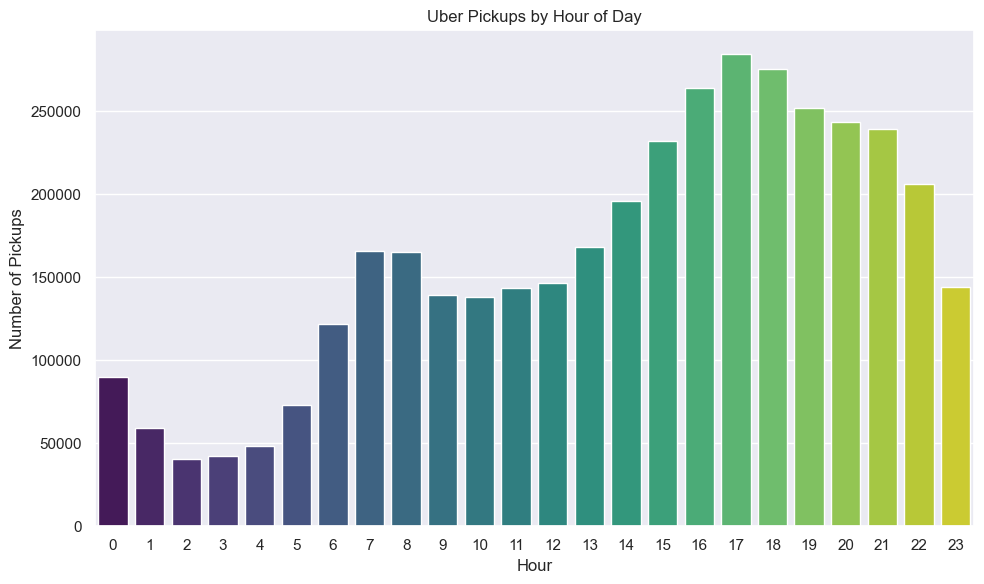

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(x='Hour', data=df, palette='viridis')
plt.title('Uber Pickups by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Pickups')
plt.tight_layout()
plt.show()

## Pickups by Day of Week
Visualize the number of Uber pickups for each day of the week.

C:\Users\holsa\AppData\Local\Temp\ipykernel_26612\2605499676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='magma')


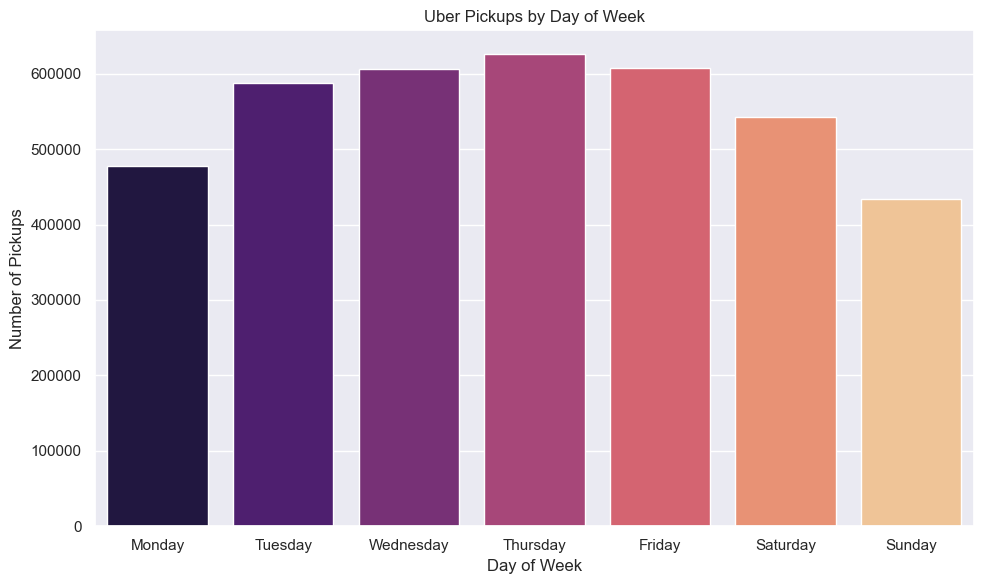

In [5]:
plt.figure(figsize=(10,6))
sns.countplot(x='DayOfWeek', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='magma')
plt.title('Uber Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.tight_layout()
plt.show()

## Heatmap of Pickups by Day and Hour
Visualize a heatmap showing the concentration of pickups by day and hour.

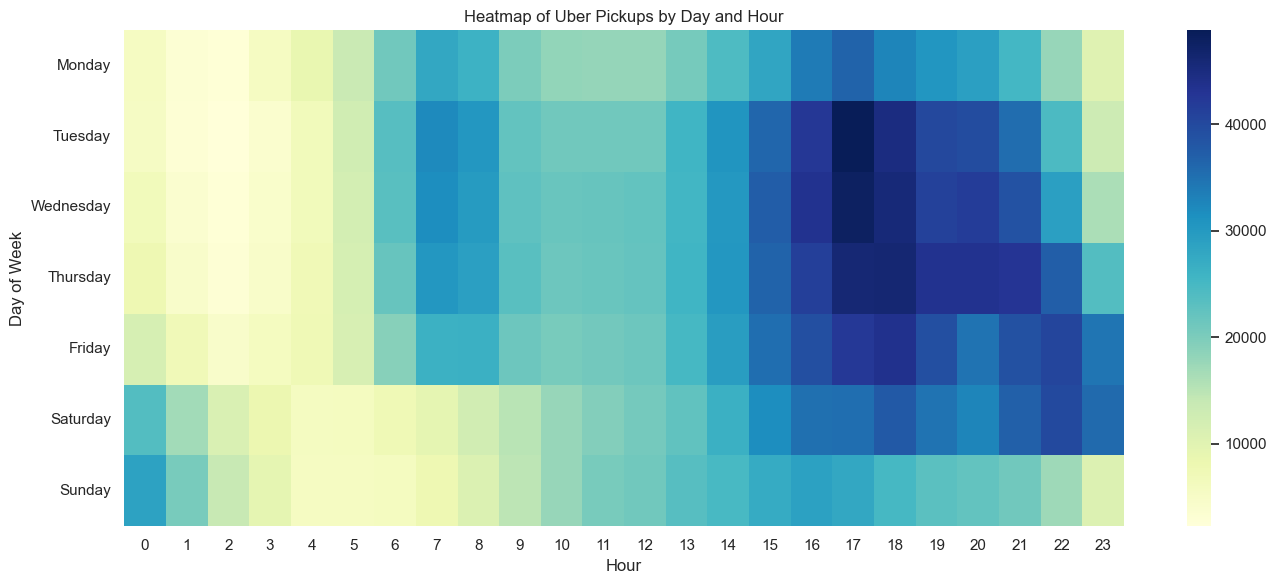

In [6]:
pivot = df.pivot_table(index='DayOfWeek', columns='Hour', values='Date/Time', aggfunc='count').reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Heatmap of Uber Pickups by Day and Hour')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()